/mnt/50BE87BDBE879A5C/blackjack/ppo/venv/lib/python3.12/site-packages/stable_baselines3/common/save_util.py:167: UserWarning: Could not deserialize object learning_rate. Consider using `custom_objects` argument to replace this object.
Exception: code() argument 13 must be str, not int
  warnings.warn(
/mnt/50BE87BDBE879A5C/blackjack/ppo/venv/lib/python3.12/site-packages/stable_baselines3/common/save_util.py:167: UserWarning: Could not deserialize object clip_range. Consider using `custom_objects` argument to replace this object.
Exception: code() argument 13 must be str, not int
  warnings.warn(
/mnt/50BE87BDBE879A5C/blackjack/ppo/venv/lib/python3.12/site-packages/stable_baselines3/common/save_util.py:167: UserWarning: Could not deserialize object lr_schedule. Consider using `custom_objects` argument to replace this object.
Exception: code() argument 13 must be str, not int
  warnings.warn(


Starting evaluation...
Episode 1000: Reward/Bet Ratio = -2.65%
Episode 2000: Reward/Bet Ratio = -5.27%
Episode 3000: Reward/Bet Ratio = -3.02%
Episode 4000: Reward/Bet Ratio = -3.23%
Episode 5000: Reward/Bet Ratio = -2.83%
Episode 6000: Reward/Bet Ratio = -2.53%
Episode 7000: Reward/Bet Ratio = -2.81%
Episode 8000: Reward/Bet Ratio = -3.04%
Episode 9000: Reward/Bet Ratio = -2.65%
Episode 10000: Reward/Bet Ratio = -2.44%
Episode 11000: Reward/Bet Ratio = -2.42%
Episode 12000: Reward/Bet Ratio = -2.24%
Episode 13000: Reward/Bet Ratio = -1.79%
Episode 14000: Reward/Bet Ratio = -1.64%
Episode 15000: Reward/Bet Ratio = -1.71%
Episode 16000: Reward/Bet Ratio = -1.61%
Episode 17000: Reward/Bet Ratio = -2.05%
Episode 18000: Reward/Bet Ratio = -1.88%
Episode 19000: Reward/Bet Ratio = -1.82%
Episode 20000: Reward/Bet Ratio = -1.64%
Episode 21000: Reward/Bet Ratio = -1.35%
Episode 22000: Reward/Bet Ratio = -1.10%
Episode 23000: Reward/Bet Ratio = -1.12%
Episode 24000: Reward/Bet Ratio = -1.08%
Ep

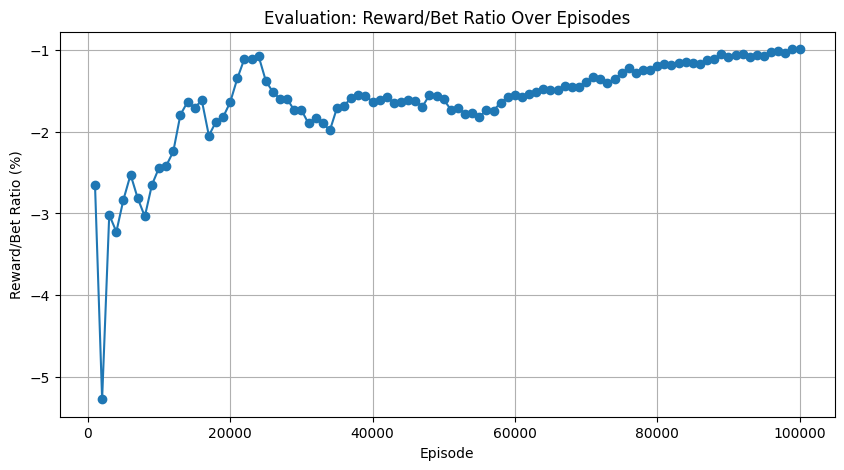

In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import random
import math
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_checker import check_env
from gymnasium.wrappers import RecordEpisodeStatistics

class BlackjackEnvInfinite(gym.Env):
    """
    Custom Blackjack environment with an infinite deck.
    
    State (MultiDiscrete):
      [player_sum, dealer_card, usable_ace, first_move]
      
      - player_sum: Sum of player's hand (0 to 31)
      - dealer_card: Dealer's face-up card (1-10; note: 0 is unused)
      - usable_ace: 0 (False) or 1 (True)
      - first_move: 1 if it's the first decision, else 0
     
    Actions (Discrete(4)):
      0: HIT      – Request another card.
      1: STK      – Stand.
      2: DBL      – Double Down (only on first move).
      3: SUR      – Surrender (only on first move).
    """
    def __init__(self, payout_blackjack=1.5):
        super(BlackjackEnvInfinite, self).__init__()
        self.action_space = spaces.Discrete(4)
        # Use a flattened observation space instead of Tuple.
        self.observation_space = spaces.MultiDiscrete([32, 11, 2, 2])
        self.payout_blackjack = payout_blackjack
        self.base_bet = 1.0
        self.reset()
    
    def _draw_card(self):
        """Draw a card from an infinite deck with equal probability."""
        # Cards: Ace=1, cards 2-9, and four 10-value cards (10, J, Q, K)
        cards = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10]
        return random.choice(cards)
    
    def _hand_value(self, hand):
        """Compute the hand's total and whether a usable ace is present."""
        total = sum(hand)
        usable_ace = 0
        # If an Ace is present and counting it as 11 doesn't bust, do so.
        if 1 in hand and total + 10 <= 21:
            total += 10
            usable_ace = 1
        return total, usable_ace
    
    def _get_observation(self):
        """Return the observation as a flattened numpy array."""
        player_total, usable = self._hand_value(self.player_hand)
        dealer_card = self.dealer_hand[0]
        first_move_val = 1 if self.first_move else 0
        return np.array([player_total, dealer_card, usable, first_move_val], dtype=np.int32)
    
    def reset(self, seed=None, options=None):
        """Reset the environment for a new round."""
        self.first_move = True
        self.done = False
        self.reward = 0.0
        
        # Deal two cards each to player and dealer.
        self.player_hand = [self._draw_card(), self._draw_card()]
        self.dealer_hand = [self._draw_card(), self._draw_card()]
        
        player_total, _ = self._hand_value(self.player_hand)
        dealer_total, _ = self._hand_value(self.dealer_hand)
        
        # Check for natural blackjack.
        if player_total == 21:
            if dealer_total == 21:
                self.done = True
                self.reward = 0.0
            else:
                self.done = True
                self.reward = self.payout_blackjack * self.base_bet
        return self._get_observation(), {}
    
    def step(self, action):
        """Take an action in the environment."""
        if self.done:
            return self._get_observation(), 0.0, True, False, {}
        
        # On moves after the first, only HIT (0) and STK (1) are allowed.
        if not self.first_move and action in [2, 3]:
            self.done = True
            return self._get_observation(), -1.0, True, False, {"illegal_action": True}
        
        if action == 0:  # HIT
            card = self._draw_card()
            self.player_hand.append(card)
            player_total, _ = self._hand_value(self.player_hand)
            if player_total > 21:
                self.done = True
                reward = -self.base_bet
            else:
                reward = 0.0
            self.first_move = False
            return self._get_observation(), reward, self.done, False, {}
        
        elif action == 1:  # STAND
            reward = self._dealer_play()
            self.done = True
            return self._get_observation(), reward, self.done, False, {}
        
        elif action == 2:  # DOUBLE DOWN
            self.first_move = False
            card = self._draw_card()
            self.player_hand.append(card)
            player_total, _ = self._hand_value(self.player_hand)
            if player_total > 21:
                reward = -2 * self.base_bet
                self.done = True
                return self._get_observation(), reward, self.done, False, {}
            reward = self._dealer_play(double_down=True)
            self.done = True
            return self._get_observation(), reward, self.done, False, {}
        
        elif action == 3:  # SURRENDER
            self.first_move = False
            self.done = True
            reward = -0.5 * self.base_bet
            return self._get_observation(), reward, self.done, False, {}
        
        else:
            self.done = True
            return self._get_observation(), -1.0, True, False, {"illegal_action": True}
    
    def _dealer_play(self, double_down=False):
        """Simulate the dealer's play and determine the outcome."""
        player_total, _ = self._hand_value(self.player_hand)
        dealer_total, _ = self._hand_value(self.dealer_hand)
        
        # Dealer draws until reaching 17 or more.
        while dealer_total < 17:
            self.dealer_hand.append(self._draw_card())
            dealer_total, _ = self._hand_value(self.dealer_hand)
        
        bet = self.base_bet * (2 if double_down else 1)
        if dealer_total > 21:
            return bet
        elif dealer_total > player_total:
            return -bet
        elif dealer_total < player_total:
            return bet
        else:
            return 0.0
    
    def render(self, mode='human'):
        """Print a simple representation of the current state."""
        player_total, usable = self._hand_value(self.player_hand)
        dealer_total, _ = self._hand_value(self.dealer_hand)
        print(f"Player hand: {self.player_hand} (Total: {player_total}, Usable Ace: {usable})")
        print(f"Dealer hand: {self.dealer_hand} (Total: {dealer_total})")

eval_env = BlackjackEnvInfinite()
check_env(eval_env)
# Load the further trained model (assumed saved as "model_further_trained")
model = PPO.load("model", env=eval_env)

# Evaluation settings
num_episodes = 100_000
reward_history = []   # stores reward for each episode
bet_history = []      # stores bet for each episode
ratio_history_eval = []  # stores cumulative Reward/Bet ratio at intervals
episode_x = []           # episodes at which ratio is recorded

wins = 0
draws = 0
losses = 0

print("Starting evaluation...")
for episode in range(1, num_episodes + 1):
    obs, _ = eval_env.reset()
    base_env = eval_env.unwrapped  # Get the underlying custom environment

    # Check if the episode terminated immediately (e.g., natural blackjack)
    if base_env.done:
        final_reward = base_env.reward
        episode_bet = base_env.base_bet
    else:
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = eval_env.step(action)
        final_reward = reward
        # Retrieve bet info from the final step; default to base bet if not provided.
        episode_bet = info.get("bet", base_env.base_bet)
    
    reward_history.append(final_reward)
    bet_history.append(episode_bet)
    
    if final_reward > 0:
        wins += 1
    elif final_reward == 0:
        draws += 1
    else:
        losses += 1
        
    # Record progress every 1000 episodes.
    if episode % 1000 == 0:
        total_reward = np.sum(reward_history)
        total_bet = np.sum(bet_history)
        ratio = (total_reward / total_bet * 100) if total_bet > 0 else 0.0
        ratio_history_eval.append(ratio)
        episode_x.append(episode)
        print(f"Episode {episode}: Reward/Bet Ratio = {ratio:.2f}%")

win_percent = wins / num_episodes * 100
draw_percent = draws / num_episodes * 100
loss_percent = losses / num_episodes * 100
avg_reward_eval = (np.sum(reward_history) / np.sum(bet_history) * 100) if np.sum(bet_history) > 0 else 0.0

print("\nFinal Evaluation Results:")
print(f"Win %: {win_percent:.2f}%")
print(f"Draw %: {draw_percent:.2f}%")
print(f"Loss %: {loss_percent:.2f}%")
print(f"Average Reward per Bet (%): {avg_reward_eval:.2f}%")

plt.figure(figsize=(10, 5))
plt.plot(episode_x, ratio_history_eval, marker='o', linestyle='-')
plt.title("Evaluation: Reward/Bet Ratio Over Episodes")
plt.xlabel("Episode")
plt.ylabel("Reward/Bet Ratio (%)")
plt.grid(True)
plt.show()

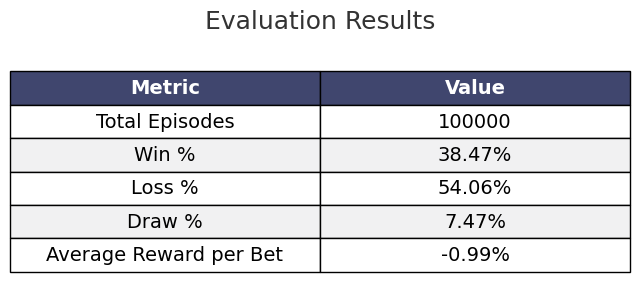

In [3]:
# Prepare table data
table_data = [
    ["Total Episodes", num_episodes],
    ["Win %", f"{win_percent:.2f}%"],
    ["Loss %", f"{loss_percent:.2f}%"],
    ["Draw %", f"{draw_percent:.2f}%"],
    ["Average Reward per Bet", f"{avg_reward_eval:.2f}%"]
]

# Create a figure and a single subplot
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')  # Turn off the axis

# Create the table and customize it
table = ax.table(cellText=table_data, colLabels=["Metric", "Value"],
                 cellLoc='center', loc='center')

# Adjust table style
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1, 2)

# Color the header and rows for a beautiful look
for (row, col), cell in table.get_celld().items():
    if row == 0:  # Header row
        cell.set_facecolor("#40466e")
        cell.set_text_props(color="w", weight="bold")
    else:
        # Alternate row colors for a more colorful effect
        if row % 2 == 0:
            cell.set_facecolor("#f1f1f2")
        else:
            cell.set_facecolor("#ffffff")

# Set a title with custom styling
plt.title("Evaluation Results", fontsize=18, color="#333333", pad=20)

# Save the figure as an image file in the 'results' folder
plt.savefig("../../results/final-model/evaluation_metrics.png", bbox_inches="tight", dpi=300)
plt.show()